# W10

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
P = np.array([[0.9, 0.1],  # p(clear tomorrow | clear today), p(cloudy tomorrow | clear today)
              [0.5, 0.5]]) # p(clear tomorrow | cloudy today), p(cloudy tomorrow | cloudy today)

In [3]:
# Initial condition: starting with a cloudy day (index 1)
state = 1  # 0: clear, 1: cloudy

# Number of days to simulate
N = 10000

# Array to store weather states
weather_states = np.zeros(N)

# Simulate the weather for N days using the transition matrix
for i in range(N):
    weather_states[i] = state
    state = np.random.choice([0, 1], p=P[state])  # Transition to the next day based on the current state


Text(0, 0.5, 'Cumulative fraction of sunny days')

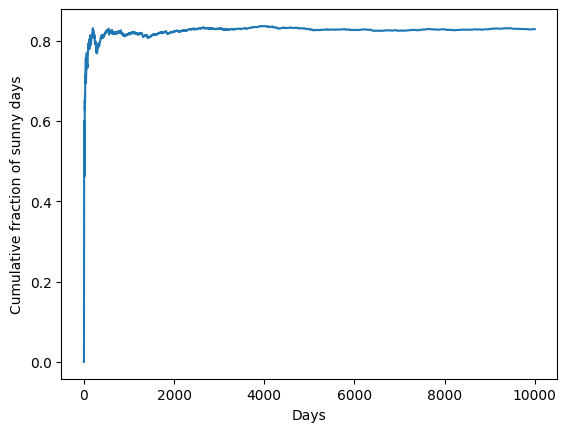

In [7]:
cumulative_sunny_fraction = np.cumsum(weather_states == 0) / (np.arange(N) + 1)

plt.plot(np.arange(N), cumulative_sunny_fraction)
plt.xlabel('Days')
plt.ylabel('Cumulative fraction of sunny days')

Text(0, 0.5, 'Density')

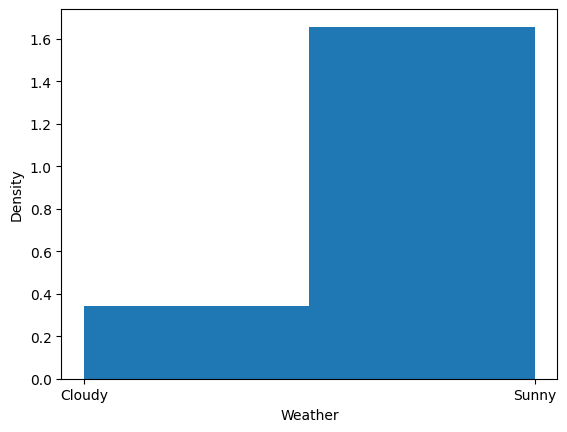

In [16]:
plt.hist((weather_states == 0).astype(int), bins=2, density=True)
plt.xticks([0, 1], ['Cloudy', 'Sunny'])
plt.xlabel('Weather')
plt.ylabel('Density')

In [18]:
# Burn-in removal (experiment with different values of burn-in)
burn_in = 1000  # number of initial samples to discard
weather_after_burn_in = weather_states[burn_in:]

# Calculate summary statistics
sunny_days = weather_after_burn_in == 0
mean_sunny_days = np.mean(sunny_days)
std_sunny_days = np.std(sunny_days)

print(f"Mean fraction of sunny days: {mean_sunny_days:.4f}")
print(f"Standard deviation of sunny days: {std_sunny_days:.4f}")


Mean fraction of sunny days: 0.8294
Standard deviation of sunny days: 0.3761
